# SingleRust vs scanpy — per-step runtime benchmark

Each pipeline step runs **one at a time**: the SingleRust (Rust) implementation and the
equivalent **scanpy** function, on the *same* input, on a bigger CZI CELLxGENE blood slice
(~50k cells). We report the **compute time only** — the Rust `.h5ad` read/write is measured
separately and excluded, so it is comparable to scanpy timed in-process.

**Methodology.** scanpy runs the canonical pipeline and saves the state *before* each step to
disk; the Rust binary (`examples/bench_step.rs`) then runs that same step on that same state.
Caveats: both use all CPU cores (Rust via rayon, scanpy via BLAS); ORA has no scanpy
equivalent so it is compared against a straightforward NumPy/SciPy implementation of the same
algorithm; single run per step (timings are indicative, not micro-benchmarked).

## Setup

In [1]:
import hdf5plugin  # registers blosc/zstd filters (SingleRust writes those); import before anndata
import os, sys, subprocess, pathlib, time, json
import numpy as np, pandas as pd
import scanpy as sc, anndata as ad
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd()
if ROOT.name == "demo":
    ROOT = ROOT.parent
DATA = ROOT / "data"; DATA.mkdir(exist_ok=True)
BENCH_INPUT = DATA / "bench_input.h5ad"
MARKERS = ROOT / "demo" / "markers.tsv"
N_CELLS = 50_000

ENV = dict(os.environ)
ENV["PATH"] = "/opt/homebrew/bin:" + str(pathlib.Path.home()/".cargo"/"bin") + ":" + ENV.get("PATH","")
BIN = ROOT / "target" / "release" / "examples" / "bench_step"

import multiprocessing
print("CPU cores:", multiprocessing.cpu_count())

def build_rust():
    print("building bench_step (release) ...")
    p = subprocess.run(["cargo","build","--release","--features","enrichment","--example","bench_step"],
                       cwd=ROOT, env=ENV, capture_output=True, text=True)
    if p.returncode: print(p.stderr[-2000:]); raise SystemExit(1)
build_rust()

def rust_step(input_path, step, *extra):
    # Run one Rust step; return (compute_seconds, read_seconds).
    cmd = [str(BIN), str(input_path), step, "-", *map(str, extra)]
    p = subprocess.run(cmd, cwd=ROOT, env=ENV, capture_output=True, text=True)
    if p.returncode:
        print(p.stdout[-1000:]); print(p.stderr[-2000:]); raise RuntimeError(f"rust step {step} failed")
    secs = {}
    for line in p.stdout.splitlines():
        k, _, v = line.partition("=")
        if k.endswith("_SECONDS"):
            secs[k] = float(v)
    return secs["STEP_SECONDS"], secs.get("READ_SECONDS", float("nan"))

def time_py(fn, *a, **k):
    t = time.perf_counter(); fn(*a, **k); return time.perf_counter() - t

results = []  # rows: step, scanpy_s, rust_s
def record(step, scanpy_s, rust_s, rust_read=None):
    results.append(dict(step=step, scanpy_s=scanpy_s, rust_s=rust_s))
    sp = scanpy_s / rust_s if rust_s else float("nan")
    extra = f" (rust read {rust_read:.2f}s)" if rust_read else ""
    print(f"[{step:9s}] scanpy {scanpy_s:7.3f}s | rust {rust_s:7.3f}s | speedup {sp:5.2f}×{extra}")

CPU cores: 18
building bench_step (release) ...


## Fetch the bigger dataset (~50k cells)

Stratified healthy-blood slice (raw counts) from the CELLxGENE Census. Skipped if it already
exists. (~800 MB; first fetch needs network.)

In [2]:
if not BENCH_INPUT.exists():
    subprocess.run([sys.executable, str(ROOT/"demo"/"prepare_data.py"),
                    "--n-cells", str(N_CELLS), "--per-type", "2000", "--out", str(BENCH_INPUT)],
                   check=True)
adata = ad.read_h5ad(BENCH_INPUT)
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
print(adata)

AnnData object with n_obs × n_vars = 50000 × 35507
    obs: 'cell_type', 'assay', 'sex', 'disease'
    var: 'feature_id', 'feature_name', 'ensembl_id', 'n_cells', 'mt'


## Step 1 — QC metrics

`qc_metrics` vs `sc.pp.calculate_qc_metrics` (mito %, counts, genes, top-N fractions, log1p).
Both run on the raw counts.

In [3]:
def scanpy_qc():
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=[50,100,200,500],
                               log1p=True, inplace=True)
s = time_py(scanpy_qc)
r, rd = rust_step(BENCH_INPUT, "qc")
record("qc", s, r, rd)

[qc       ] scanpy   4.579s | rust   1.073s | speedup  4.27× (rust read 0.23s)


## Step 2 — Normalize total (→ 10,000)

`normalize_expression` vs `sc.pp.normalize_total`. Input is raw counts; afterwards we save the
scanpy-normalized state for the next step's Rust input.

In [4]:
def scanpy_norm():
    sc.pp.normalize_total(adata, target_sum=1e4)
s = time_py(scanpy_norm)
r, rd = rust_step(BENCH_INPUT, "normalize")    # rust normalizes the same raw counts
record("normalize", s, r, rd)

STATE_NORM = DATA / "bench_state_norm.h5ad"
adata.write_h5ad(STATE_NORM)                    # scanpy-normalized state for the log1p step

[normalize] scanpy   0.080s | rust   0.010s | speedup  7.82× (rust read 0.21s)


## Step 3 — log1p

In [5]:
def scanpy_log1p():
    sc.pp.log1p(adata)
s = time_py(scanpy_log1p)
r, rd = rust_step(STATE_NORM, "log1p")
record("log1p", s, r, rd)

STATE_LOGNORM = DATA / "bench_state_lognorm.h5ad"
adata.write_h5ad(STATE_LOGNORM)                 # log-normalized state (for hvg + ora)

[log1p    ] scanpy   0.193s | rust   0.143s | speedup  1.35× (rust read 0.21s)


## Step 4 — Highly variable genes (top 2000, Seurat)

`compute_highly_variable_genes` vs `sc.pp.highly_variable_genes(flavor="seurat")`.

In [6]:
def scanpy_hvg():
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
s = time_py(scanpy_hvg)
r, rd = rust_step(STATE_LOGNORM, "hvg")
record("hvg", s, r, rd)

STATE_HVG = DATA / "bench_state_hvg.h5ad"
adata.write_h5ad(STATE_HVG)                     # log-norm + highly_variable mask (for pca)

[hvg      ] scanpy   0.825s | rust   0.118s | speedup  7.00× (rust read 0.21s)


## Step 5 — PCA (50 comps, randomized SVD, HVG subset)

`run_pca_inplace` vs `sc.pp.pca`. Both use the same scanpy-selected HVGs and randomized SVD.

In [7]:
def scanpy_pca():
    sc.pp.pca(adata, n_comps=50, svd_solver="randomized", use_highly_variable=True, random_state=42)
s = time_py(scanpy_pca)
r, rd = rust_step(STATE_HVG, "pca")
record("pca", s, r, rd)

/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


/Users/iandriver/Downloads/SingleRust/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:273: UserWarning: svd_solver 'randomized' does not work with sparse input. Densifying the array. This may take a very large amount of memory.
  warnings.warn(


[pca      ] scanpy   6.732s | rust   1.043s | speedup  6.46× (rust read 0.21s)


## Step 6 — ORA (no scanpy equivalent → NumPy/SciPy reference)

`run_ora` vs an equivalent NumPy/SciPy implementation of the same per-cell hypergeometric ORA.

In [8]:
from scipy.sparse import csr_matrix
from scipy.stats import hypergeom

def py_ora(a, net_tsv, n_up=50, n_background=None):
    gene_ix = {g: i for i, g in enumerate(a.var_names)}
    paths = {}
    for line in pathlib.Path(net_tsv).read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"): continue
        p, g = line.split("\t")[:2]
        if g in gene_ix: paths.setdefault(p, set()).add(gene_ix[g])
    pnames = list(paths)
    rows, cols = [], []
    for j, p in enumerate(pnames):
        for gi in paths[p]:
            rows.append(gi); cols.append(j)
    ind = csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(a.n_vars, len(pnames)))
    Ksz = np.asarray(ind.sum(0)).ravel()
    N = n_background or a.n_vars
    X = a.X.tocsr()
    # per-cell top-`n_up` gene membership
    indices, indptr = [], [0]
    for i in range(a.n_obs):
        lo, hi = X.indptr[i], X.indptr[i+1]
        idx, val = X.indices[lo:hi], X.data[lo:hi]
        sel = idx[np.argpartition(val, -n_up)[-n_up:]] if (hi-lo) > n_up else idx
        indices.extend(sel.tolist()); indptr.append(len(indices))
    mem = csr_matrix((np.ones(len(indices)), indices, indptr), shape=(a.n_obs, a.n_vars))
    draws = np.asarray(mem.sum(1)).ravel().astype(int)
    overlap = np.asarray((mem @ ind).todense()).astype(int)
    K = np.broadcast_to(Ksz.astype(int), overlap.shape)
    n = np.broadcast_to(draws[:, None], overlap.shape)
    pv = hypergeom.sf(overlap - 1, N, K, n)
    pv = np.where(overlap > 0, pv, 1.0)
    return (-np.log10(np.clip(pv, 1e-300, None))).astype(np.float32)

s = time_py(py_ora, adata, MARKERS)
r, rd = rust_step(STATE_LOGNORM, "ora", MARKERS)
record("ora", s, r, rd)

[ora      ] scanpy   1.434s | rust   0.443s | speedup  3.24× (rust read 0.21s)


## Results

In [9]:
df = pd.DataFrame(results)
df["speedup_x"] = df["scanpy_s"] / df["rust_s"]
df = df[["step","scanpy_s","rust_s","speedup_x"]]
display(df.style.format({"scanpy_s":"{:.3f}","rust_s":"{:.3f}","speedup_x":"{:.2f}×"}))
print(f"\ntotal: scanpy {df.scanpy_s.sum():.2f}s | rust {df.rust_s.sum():.2f}s "
      f"| overall {df.scanpy_s.sum()/df.rust_s.sum():.2f}×")

,step,scanpy_s,rust_s,speedup_x
0,qc,4.579,1.073,4.27×
1,normalize,0.080,0.010,7.82×
2,log1p,0.193,0.143,1.35×
3,hvg,0.825,0.118,7.00×
4,pca,6.732,1.043,6.46×
5,ora,1.434,0.443,3.24×



total: scanpy 13.84s | rust 2.83s | overall 4.89×


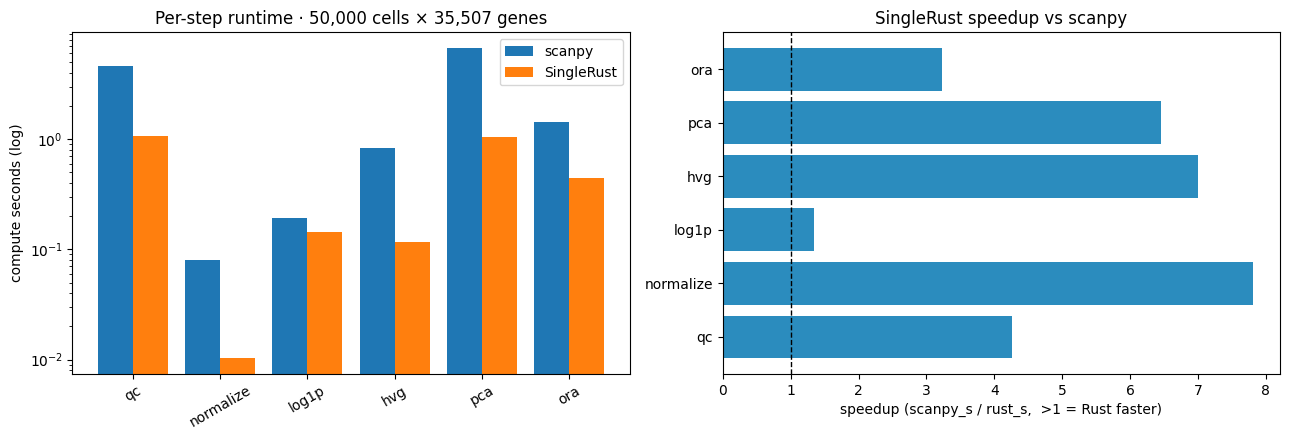

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(df)); w = 0.4
ax[0].bar(x-w/2, df.scanpy_s, w, label="scanpy")
ax[0].bar(x+w/2, df.rust_s, w, label="SingleRust")
ax[0].set_xticks(x); ax[0].set_xticklabels(df.step, rotation=30)
ax[0].set_ylabel("compute seconds (log)"); ax[0].set_yscale("log")
ax[0].set_title(f"Per-step runtime · {adata.n_obs:,} cells × {adata.n_vars:,} genes"); ax[0].legend()

colors = ["#2b8cbe" if v>=1 else "#d7301f" for v in df.speedup_x]
ax[1].barh(df.step, df.speedup_x, color=colors)
ax[1].axvline(1.0, color="k", lw=1, ls="--")
ax[1].set_xlabel("speedup (scanpy_s / rust_s,  >1 = Rust faster)")
ax[1].set_title("SingleRust speedup vs scanpy")
plt.tight_layout(); plt.show()

## Notes

- **Compute only.** Rust `.h5ad` read/write is excluded (printed separately as `READ_SECONDS`).
  scanpy times are pure in-process compute. This isolates the algorithm cost.
- **Same input per step.** Each Rust step runs on the state scanpy produced just before that
  step, so both see identical data.
- **Parallelism.** Both use all cores. Numbers depend on the machine; treat them as indicative.
- **ORA** has no scanpy function; it is compared to a straightforward NumPy/SciPy implementation
  of the identical algorithm (decoupler is the tuned scverse equivalent).